# Notebook 3 – Conduction velocity

**Workflow:** load → preprocess → delay map → CV map → innervation zone

Muscle fibre conduction velocity (CV) is a key index of muscle fibre diameter  
and fatigue.  It can be estimated from HD-EMG by tracking the negative peak  
of the eCMUAP propagating along muscle fibres.

**You will learn how to:**
1. Build a delay map (time-of-negative-peak per electrode).
2. Overlay a quiver plot showing propagation direction.
3. Estimate CV per electrode column using cross-correlation.
4. Identify the innervation zone (sign-flip in CV).


## 1 · Imports & setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecmuap_interface.utils.trigger import Trigger
from ecmuap_interface.core.emg_data import EMGData
from ecmuap_interface.core.HD_emg import HDEMG
from ecmuap_interface.views.HDemg_view import HDEMGView
from ecmuap_interface.probe_lib.get_probes import NeuroNexus_H32
from ecmuap_interface.utils.loaders import Ripple_to_array
from ecmuap_interface.utils.probes import make_uniform_probe_from_base
from ecmuap_interface.utils.spatial_filters import IB2_kernel
from ecmuap_interface.utils.velocity import (
    compute_delay_map, compute_xcorr_cv, compute_velocity_map
)
from ecmuap_interface.utils.probes import (
    reshape_to_grid, get_grid_shape_from_probe, get_grid_indices_from_probe
)

DATA_FILE = Path("../data/test_emg.hdf5")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110})


## 2 · Load, preprocess, interpolate & spatially filter

In [2]:
df      = pd.read_hdf(DATA_FILE)
probe   = NeuroNexus_H32()
time    = df["time"].values
data    = Ripple_to_array(df, probe)
trigger = Trigger(df["Tr0 "].values, time)

emg = EMGData(data=data, time=time, trigger=trigger)
emg.HPF(10); emg.notch(50.0); emg.LPF(1_000); emg.remove_baseline()

# Interpolate → uniform grid → IB2 spatial filter
uniform_probe = make_uniform_probe_from_base(probe)
hd   = HDEMG(emg=emg, probe=probe)
emg_interp = hd.interpolate_to_probe(uniform_probe)

hd_interp = HDEMG(emg=emg_interp, probe=uniform_probe)
emg_ib2   = hd_interp.spatial_filter(IB2_kernel)
hd_ib2    = HDEMG(emg=emg_ib2, probe=uniform_probe)
view      = HDEMGView(hd_ib2)

T_PRE, T_POST = 1e-3, 15e-3
print("Pipeline ready — IB2-filtered HD-EMG on uniform grid.")


Pipeline ready — IB2-filtered HD-EMG on uniform grid.


## 3 · Delay map

The **delay map** assigns to each electrode the time (relative to the trigger)  
at which the eCMUAP negative peak occurs.

- Electrodes near the **innervation zone (IZ)** have the smallest delay  
  (fibres start close to the motor end-plate).
- Delay increases with distance from the IZ as the action potential propagates.


In [3]:
from ecmuap_interface.views.eCMUAP_view import eCMUAPView

avg    = eCMUAPView(emg_ib2).average(T_PRE, T_POST, skip_start=3, skip_end=3, reject=True)
delays = compute_delay_map(avg, emg_ib2.fs)   # (n_channels,) – time in ms

print(f"Delay range: {np.nanmin(delays):.2f} – {np.nanmax(delays):.2f} ms")


Delay range: 4.43 – 9.80 ms


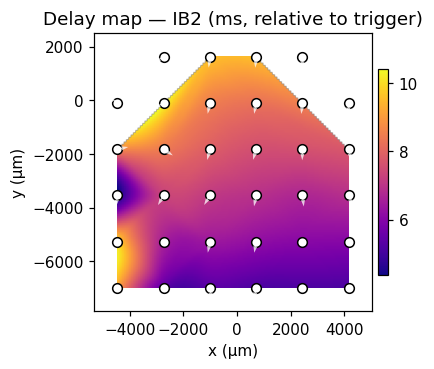

In [4]:
fig, ax = view.plot_delay_map(
    T_PRE, T_POST,
    skip_start=3, skip_end=3,
    reject=True,
    show_quiver=True,    # overlay propagation-direction arrows
    cmap="plasma",
)
ax.set_title("Delay map — IB2 (ms, relative to trigger)")
plt.tight_layout()


### 3.1 · Interpreting the quiver overlay

Each arrow points in the local propagation direction (gradient of the delay map).  
Arrows diverging from a central band indicate an innervation zone at that location.


## 4 · Cross-correlation CV map

The cross-correlation method estimates CV by finding the time lag that  
maximises the cross-correlation between adjacent electrode pairs along the  
muscle fibre direction.

`compute_xcorr_cv(avg_grid, pitch_um, fs, axis)` returns:
- `cv_map` – shape `(n_rows−1, n_cols)` or `(n_rows, n_cols−1)` depending on `axis`
- `lags` – corresponding lag values

A **sign change** in consecutive CV estimates along a column flags the innervation zone:  
fibres propagate *away* from the IZ, so CV flips sign on either side.


In [5]:
avg_grid = reshape_to_grid(avg, uniform_probe)
pitch    = float(uniform_probe.annotations["pitch_um"])

# axis=0 → CV estimated along columns (muscle fibre direction = ↓)
cv_map, lags = compute_xcorr_cv(avg_grid, pitch, emg_ib2.fs, axis=0)

print(f"CV map shape: {cv_map.shape}")
print(f"CV range    : {np.nanmin(cv_map):.2f} – {np.nanmax(cv_map):.2f} m/s")
print(f"Median |CV| : {np.nanmedian(np.abs(cv_map)):.2f} m/s")


CV map shape: (5, 6)
CV range    : -4.31 – 1.55 m/s
Median |CV| : 2.00 m/s


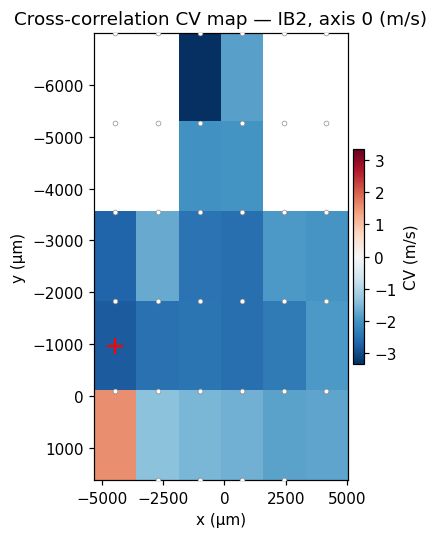

In [6]:
fig, ax = view.plot_cv_map(
    T_PRE, T_POST,
    skip_start=3, skip_end=3,
    reject=True,
    axis=0,
    cmap="RdBu_r",
    mark_iz=True,    # mark sign-flip positions (IZ candidates) with red crosses
)
ax.set_title("Cross-correlation CV map — IB2, axis 0 (m/s)")
plt.tight_layout()


### 4.1 · Reading the CV map

| Colour | Meaning |
|--------|---------|
| Blue (negative) | Fibre propagates **upward** (toward distal tendon) |
| Red (positive) | Fibre propagates **downward** (toward proximal tendon) |
| Red `+` marker | IZ candidate (sign flip between adjacent rows) |

Typical skeletal muscle CV: **3–6 m/s**.


## 5 · Gradient-based velocity field

`compute_velocity_map` converts the delay grid to a local velocity vector  
using finite differences (∂delay/∂x, ∂delay/∂y).


In [7]:
n_rows, n_cols = get_grid_shape_from_probe(uniform_probe)
delay_grid     = np.full((n_rows, n_cols), np.nan)
grid_idx       = get_grid_indices_from_probe(uniform_probe)

for ch, (r, c) in grid_idx.items():
    delay_grid[r, c] = delays[ch]

speed_grid, vx, vy = compute_velocity_map(delay_grid, pitch)

print(f"Speed range: {np.nanmin(speed_grid):.2f} – {np.nanmax(speed_grid):.2f} m/s")
print(f"Median speed: {np.nanmedian(speed_grid):.2f} m/s")


Speed range: 0.43 – 4.15 m/s
Median speed: 1.92 m/s


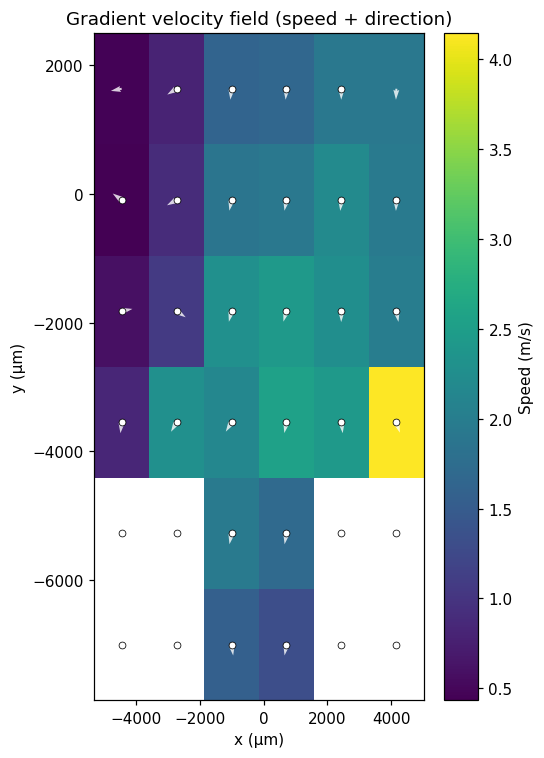

In [8]:
pos   = uniform_probe.contact_positions
x_u   = np.unique(np.round(pos[:, 0], 4))
y_u   = np.unique(np.round(pos[:, 1], 4))
X, Y  = np.meshgrid(x_u, y_u)

fig, ax = plt.subplots(figsize=(5, 7))
pcm = ax.pcolormesh(X, Y, speed_grid, cmap="viridis", shading="auto")
plt.colorbar(pcm, ax=ax, label="Speed (m/s)")

mag = np.sqrt(vx**2 + vy**2 + 1e-12)
fm  = np.isfinite(vx) & np.isfinite(vy)
ax.quiver(X[fm], Y[fm], (vx/mag)[fm], (vy/mag)[fm],
          scale=30, width=0.006, color="white", alpha=0.8)

ax.scatter(pos[:, 0], pos[:, 1], c="white", s=20,
           edgecolors="k", linewidths=0.5, zorder=5)
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Gradient velocity field (speed + direction)")
plt.tight_layout()


## 6 · Summary

| Topic | API used |
|-------|---------|
| Delay map | `compute_delay_map(avg, fs)` |
| Delay map plot | `HDEMGView.plot_delay_map` |
| Cross-correlation CV | `compute_xcorr_cv(avg_grid, pitch, fs, axis)` |
| CV map plot | `HDEMGView.plot_cv_map` |
| Gradient velocity | `compute_velocity_map(delay_grid, pitch)` |

**Next:** [Notebook 4](04_full_pipeline.ipynb) – full pipeline with epoch rejection and CSV export.
